# Moving Average (MA) Processes

At each time step a fresh random **shock** arrives -- think of it as the news of the day.
In a moving-average process, the value now is that shock plus a fading echo of the shocks
just before it:

$$X[n] = 	ext{mean} + arepsilon[n] + 	heta_1\,arepsilon[n-1] + \dots + 	heta_q\,arepsilon[n-q]$$

The echo lasts exactly $q$ steps and then stops dead, so two values more than $q$ apart share
no shocks at all and are completely uncorrelated. That sharp cutoff is the signature of a
moving-average process.

Despite the name, this is **not** the everyday "average of the last few values": it averages
the recent *shocks*, not the recent values, and it never looks at its own past.

In [1]:
from symbulate import *

## Create a process and draw a path

In [2]:
X = MA(coefs=[0.8, 0.5])   # an MA(2): echoes of the last two shocks
path = X.draw()
[round(float(path[n]), 2) for n in range(10)]

[0.35, -0.87, -1.57, -0.4, -1.46, 0.19, -0.39, -0.09, -0.35, -0.45]

## Simulate and plot sample paths

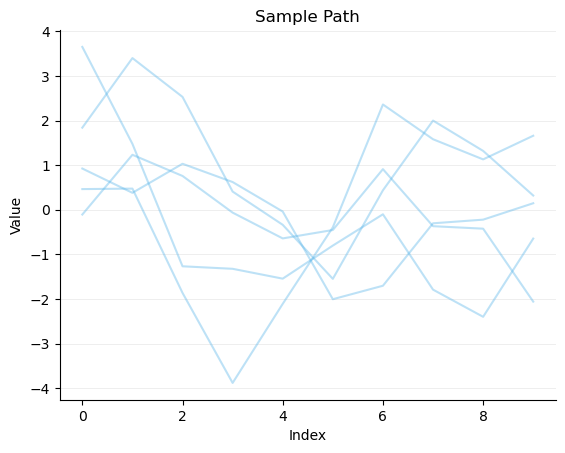

In [3]:
X.sim(5).plot()

## How many shocks are echoed

`coefs` holds one weight per past shock, so its length is the order $q$. With no coefficients
at all there is no echo, and the process is just independent noise.

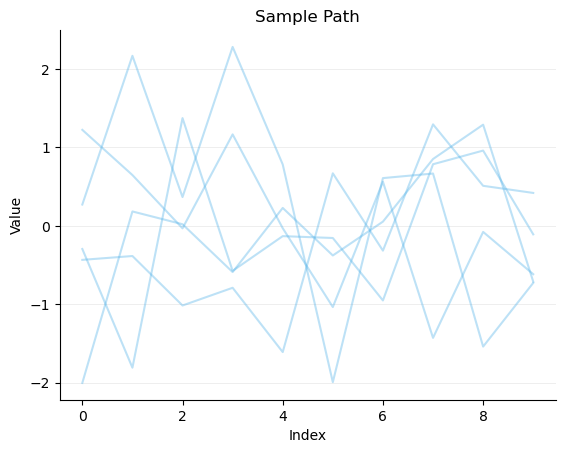

In [4]:
MA(coefs=[]).sim(5).plot()

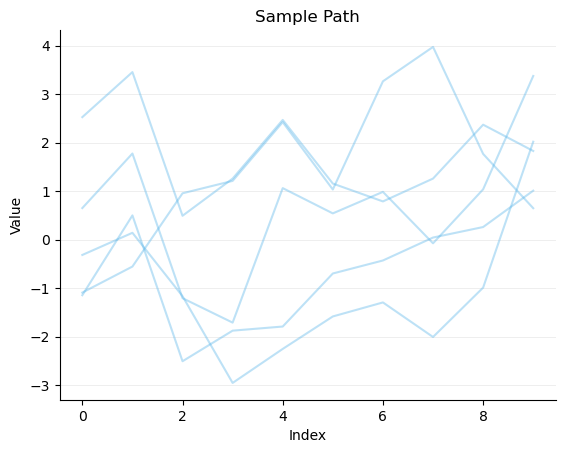

In [5]:
MA(coefs=[0.9, 0.9, 0.9, 0.9, 0.9]).sim(5).plot()

A longer echo makes the path visibly smoother: neighbouring values now share several shocks,
so the process wanders instead of jumping around.

## Choosing the shocks

The shocks are `Normal(0, 1)` by default, but any distribution works.

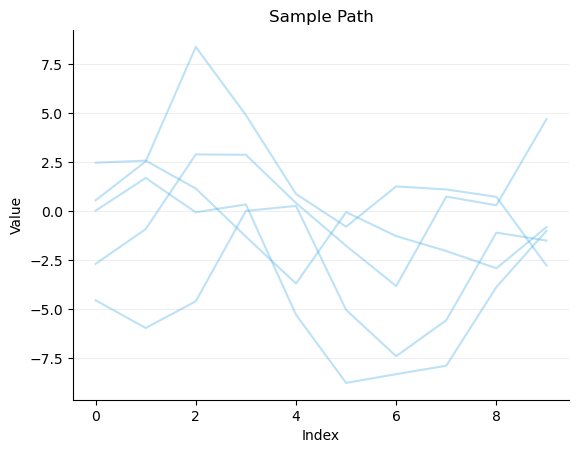

In [6]:
MA(coefs=[0.8, 0.5], noise_dist=Normal(0, 3)).sim(5).plot()

## The level the process varies around

In [7]:
Y = MA(coefs=[0.8, 0.5], mean=10)
Y[20].sim(1000).mean()

10.084085461270266

## The value at a fixed time

Currently Showing: Histogram (Default)
Alternative Plots: Rug Plot (type = "rug"), Density Plot (type = "density"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


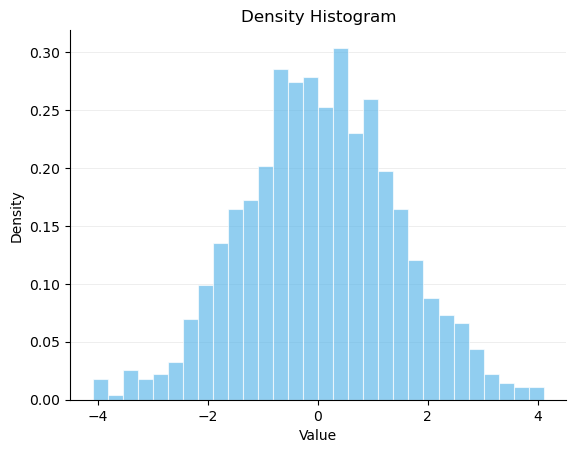

In [8]:
X[10].sim(1000).plot()

Its mean is close to 0 and its variance is close to
$1 + 0.8^2 + 0.5^2 = 1.89$, the variance of an MA(2) with these coefficients.

In [9]:
values = X[10].sim(1000)
values.mean(), values.var()

(0.020389084856337766, 1.8986155545032244)

## Every value has the same distribution

An MA process is defined over *all* time, with no beginning, which is what makes every one of
its values have the same distribution. Simulating it has to start somewhere, though, and
`X[0]` needs the $q$ shocks from *before* time 0. Symbulate simulates those too, so the
process is already running when you read the first value. Had they been left out, `X[0]` would
have had no echoes and `X[1]` only one, making the first few values artificially small -- and
any variance or correlation measured from the start of the path would come out wrong. Drawing
$q$ extra shocks costs almost nothing and makes the simulation match the definition exactly,
so there is no setting to configure.

You can see it in the variance, which is the same at the very first value as it is much later:

In [10]:
for n in [0, 1, 2, 10, 50]:
    print(n, round(float(X[n].sim(1000).var()), 2))

0 1.81
1 2.03
2 1.95


10 1.79


50 1.86


## The cutoff: correlation disappears after lag q

This is what makes a moving-average process worth naming. Values 1 or 2 steps apart share
shocks and so are correlated; values 3 or more apart share none and are uncorrelated.

In [11]:
paths = [MA(coefs=[0.8, 0.5]).draw() for _ in range(2000)]

for lag in [1, 2, 3, 4]:
    first = [float(p[0]) for p in paths]
    later = [float(p[lag]) for p in paths]
    m1 = sum(first) / len(first)
    m2 = sum(later) / len(later)
    cov = sum((a - m1) * (b - m2) for a, b in zip(first, later)) / len(first)
    s1 = (sum((a - m1) ** 2 for a in first) / len(first)) ** 0.5
    s2 = (sum((b - m2) ** 2 for b in later) / len(later)) ** 0.5
    print("lag", lag, "correlation", round(cov / (s1 * s2), 3))

lag 1 correlation 0.626


lag 2 correlation 0.238
lag 3 correlation -0.021
lag 4 correlation 0.006


Lags 1 and 2 show real correlation; lags 3 and beyond are essentially zero. An autoregressive
process, by contrast, would show correlation that fades gradually but never quite reaches zero.